# K-Means Clustering

---

## Table of Contents
1. [The Objective Function](#1-objective-function)
2. [Lloyd's Algorithm — E-step and M-step](#2-lloyds-algorithm)
3. [Convergence Properties](#3-convergence-properties)
4. [Choosing K — Elbow Method & Silhouette Score](#4-choosing-k)
5. [Initialisation — K-Means++](#5-initialisation)
6. [Limitations & When K-Means Fails](#6-limitations)

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import os

os.makedirs('img', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': '#0f0f0f', 'axes.facecolor': '#1a1a1a',
    'axes.edgecolor': '#444', 'axes.labelcolor': '#ccc',
    'xtick.color': '#888', 'ytick.color': '#888', 'text.color': '#eee',
    'grid.color': '#2a2a2a', 'grid.linewidth': 0.8,
    'font.family': 'monospace', 'axes.titlesize': 12, 'axes.labelsize': 11,
})
ACCENT = '#00e5ff'
ORANGE = '#ff6d00'
GREEN  = '#69ff47'
RED    = '#ff4d6d'
PURPLE = '#c77dff'
YELLOW = '#ffd60a'
CLUSTER_COLORS = [ACCENT, ORANGE, GREEN, RED, PURPLE, YELLOW]

---
## 1. The Objective Function

K-Means minimises the **Within-Cluster Sum of Squares (WCSS)**, also called **inertia**:

$$\mathcal{L}(\mu_1,\ldots,\mu_K, C_1,\ldots,C_K) = \sum_{k=1}^K \sum_{i \in C_k} \|x_i - \mu_k\|^2$$

where:
- $K$ — number of clusters (chosen by the user)
- $C_k$ — set of sample indices assigned to cluster $k$
- $\mu_k = \frac{1}{|C_k|}\sum_{i \in C_k} x_i$ — centroid of cluster $k$

This objective is the total squared distance of each point from its assigned centroid.

### Why the Centroid Minimises WCSS

For a fixed assignment, the optimal $\mu_k$ minimises $\sum_{i \in C_k}\|x_i - \mu_k\|^2$. Taking the derivative:
$$\frac{\partial}{\partial \mu_k}\sum_{i \in C_k}\|x_i - \mu_k\|^2 = -2\sum_{i \in C_k}(x_i - \mu_k) = 0$$
$$\implies \mu_k = \frac{1}{|C_k|}\sum_{i \in C_k} x_i$$

The mean is the unique minimiser — same derivation as OLS.

### The Joint Optimisation Problem

Optimising over both assignments $\{C_k\}$ and centroids $\{\mu_k\}$ simultaneously is **NP-hard** — the number of possible partitions into $K$ clusters is the Stirling number of the second kind $S(n,K)$, which grows super-exponentially. Lloyd's algorithm finds a **local minimum** via alternating optimisation.

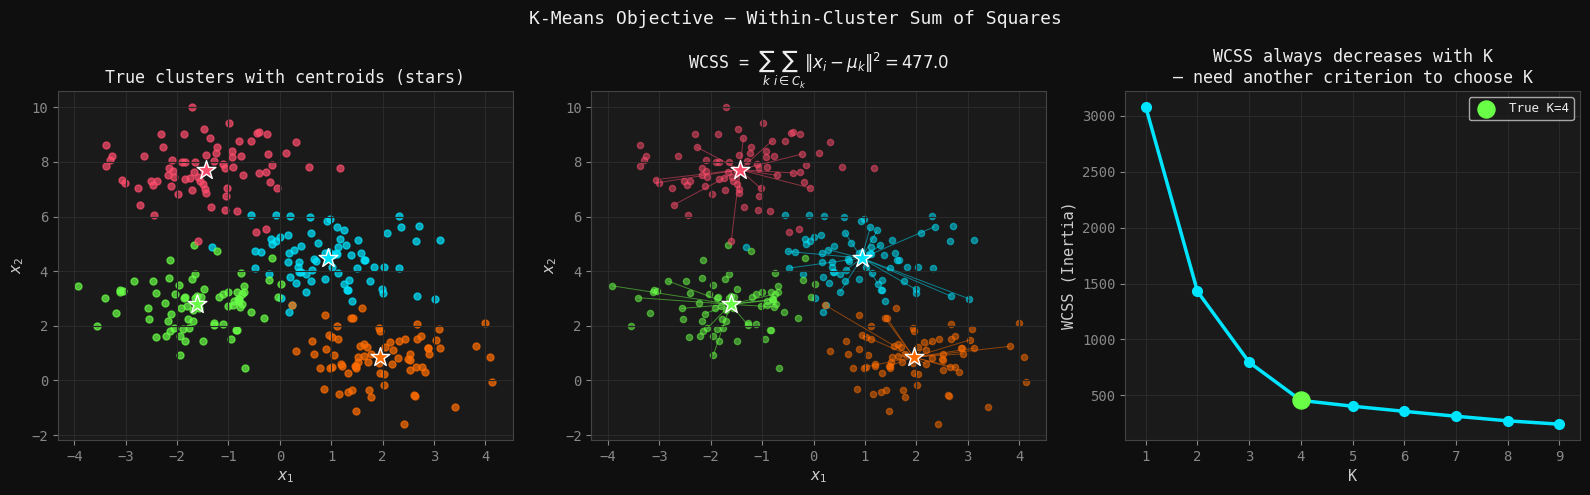

In [2]:
np.random.seed(0)
X_km, y_km = make_blobs(n_samples=300, centers=4, cluster_std=0.9, random_state=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('K-Means Objective — Within-Cluster Sum of Squares', fontsize=13)

# Labelled clusters
ax = axes[0]
for k in range(4):
    mask = y_km == k
    ax.scatter(X_km[mask,0], X_km[mask,1], color=CLUSTER_COLORS[k], s=25, alpha=0.7)
    centroid = X_km[mask].mean(axis=0)
    ax.scatter(*centroid, color=CLUSTER_COLORS[k], s=200, marker='*', zorder=6,
               edgecolors='white', linewidth=1)
ax.set_title('True clusters with centroids (stars)')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.grid(True)

# WCSS: draw distances to centroid
ax = axes[1]
for k in range(4):
    mask = y_km == k
    pts = X_km[mask]
    centroid = pts.mean(axis=0)
    ax.scatter(pts[:,0], pts[:,1], color=CLUSTER_COLORS[k], s=20, alpha=0.5)
    ax.scatter(*centroid, color=CLUSTER_COLORS[k], s=200, marker='*', zorder=6,
               edgecolors='white', linewidth=1)
    for pt in pts[::5]:
        ax.plot([pt[0], centroid[0]], [pt[1], centroid[1]],
                color=CLUSTER_COLORS[k], lw=0.7, alpha=0.5)
wcss = sum(np.sum((X_km[y_km==k] - X_km[y_km==k].mean(axis=0))**2) for k in range(4))
ax.set_title(f'WCSS = $\\sum_k\\sum_{{i\\in C_k}}\\|x_i-\\mu_k\\|^2 = {wcss:.1f}$')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.grid(True)

# WCSS for different K: show why K=4 is optimal here
ax = axes[2]
wcss_k = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    km.fit(X_km)
    wcss_k.append(km.inertia_)
ax.plot(range(1,10), wcss_k, color=ACCENT, lw=2.5, marker='o', ms=7)
ax.scatter(4, wcss_k[3], color=GREEN, s=150, zorder=5, label='True K=4')
ax.set_xlabel('K'); ax.set_ylabel('WCSS (Inertia)')
ax.set_title('WCSS always decreases with K\n— need another criterion to choose K')
ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.savefig('img/km01_objective.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Lloyd's Algorithm — E-step and M-step

Lloyd's algorithm alternates between two steps until convergence:

**E-step (Assignment)**: assign each point to its nearest centroid:
$$C_k^{(t)} = \left\{ i : \|x_i - \mu_k^{(t)}\|^2 \leq \|x_i - \mu_j^{(t)}\|^2 \; \forall j \neq k \right\}$$

**M-step (Update)**: recompute centroids as the mean of their assigned points:
$$\mu_k^{(t+1)} = \frac{1}{|C_k^{(t)}|}\sum_{i \in C_k^{(t)}} x_i$$

The name comes from the EM algorithm (Expectation-Maximisation) — K-Means is a hard-assignment version of the GMM EM algorithm (covered in `08_gmm_em.ipynb`).

**Complexity per iteration**: $\mathcal{O}(n \cdot K \cdot p)$ — for each of $n$ points, compute distances to all $K$ centroids in $\mathbb{R}^p$.

**Typical convergence**: 10–100 iterations for well-separated clusters.

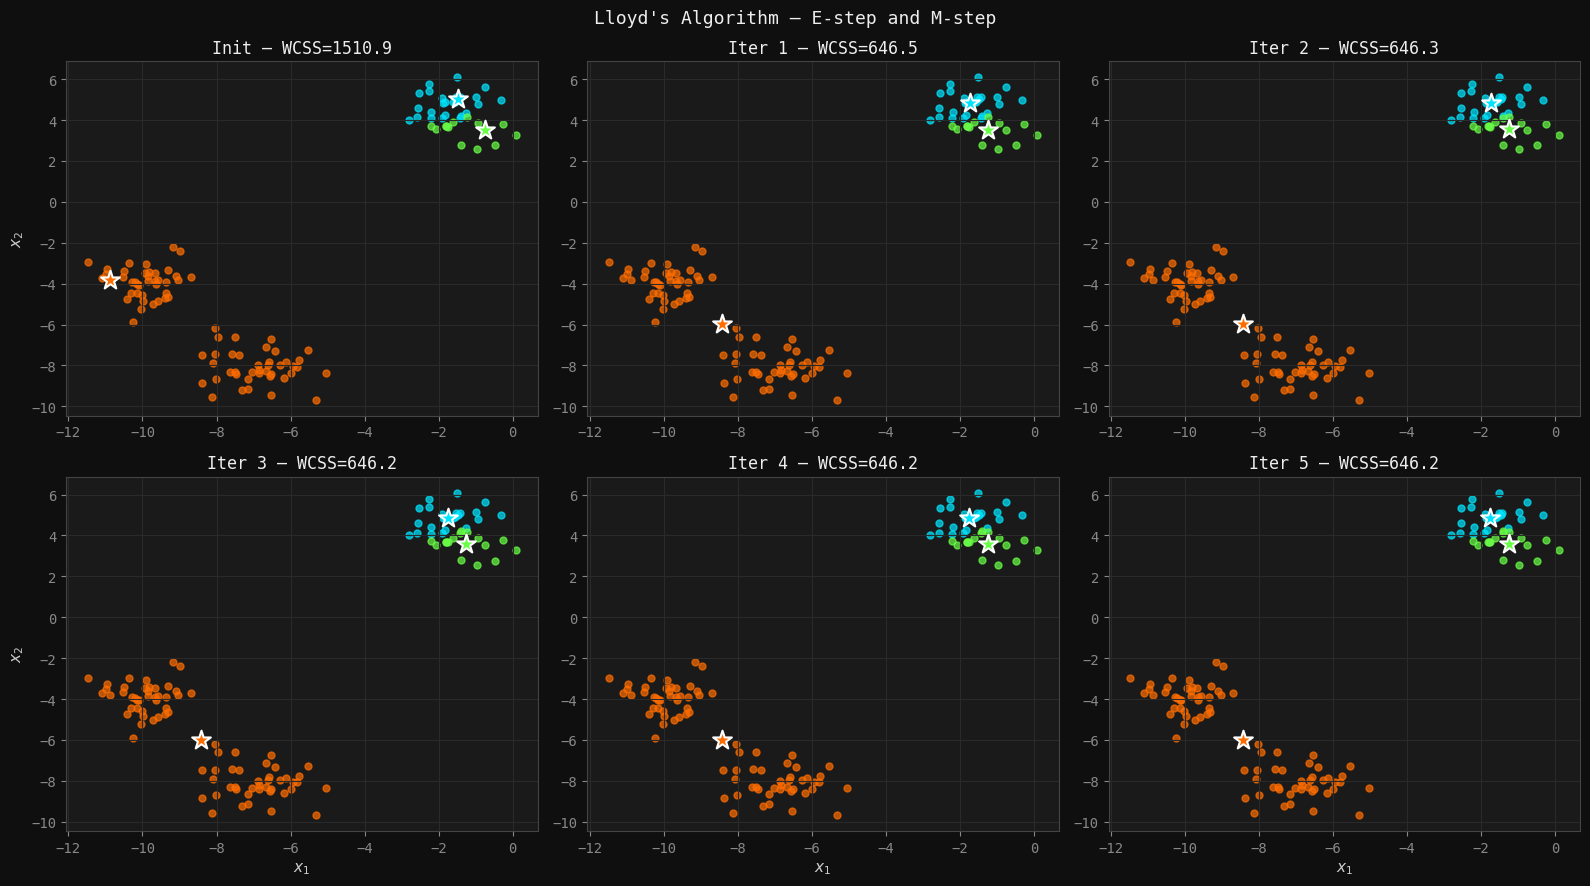

In [3]:
np.random.seed(1)
X_iter, _ = make_blobs(n_samples=120, centers=3, cluster_std=0.8, random_state=1)

def kmeans_step(X, centroids):
    dists = np.array([[np.sum((x - c)**2) for c in centroids] for x in X])
    labels = np.argmin(dists, axis=1)
    new_centroids = np.array([X[labels==k].mean(axis=0) if (labels==k).any()
                               else centroids[k] for k in range(len(centroids))])
    return labels, new_centroids

# Random init
K = 3
np.random.seed(5)
centroids = X_iter[np.random.choice(len(X_iter), K, replace=False)]

steps = []
labels, _ = kmeans_step(X_iter, centroids)
steps.append((centroids.copy(), labels.copy()))
for _ in range(5):
    labels, centroids = kmeans_step(X_iter, centroids)
    steps.append((centroids.copy(), labels.copy()))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Lloyd's Algorithm — E-step and M-step", fontsize=13)

for idx, (ax, step_idx) in enumerate(zip(axes.ravel(), [0,1,2,3,4,5])):
    c, l = steps[step_idx]
    for k in range(K):
        mask = l == k
        ax.scatter(X_iter[mask,0], X_iter[mask,1],
                   color=CLUSTER_COLORS[k], s=25, alpha=0.7)
        ax.scatter(*c[k], color=CLUSTER_COLORS[k], s=200,
                   marker='*', zorder=6, edgecolors='white', linewidth=1.5)
    wcss_s = sum(np.sum((X_iter[l==k] - c[k])**2) for k in range(K) if (l==k).any())
    step_type = 'Init' if step_idx == 0 else f'Iter {step_idx}'
    ax.set_title(f'{step_type} — WCSS={wcss_s:.1f}')
    ax.grid(True)
    if step_idx >= 3: ax.set_xlabel('$x_1$')
    if step_idx % 3 == 0: ax.set_ylabel('$x_2$')

plt.tight_layout()
plt.savefig('img/km02_lloyds.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Convergence Properties

### Monotone Decrease of WCSS

Lloyd's algorithm **monotonically decreases** the objective at every step:

- **E-step**: reassigning each point to its nearest centroid can only decrease or maintain WCSS — any reassignment that increases distance would not be chosen.
- **M-step**: the mean is the minimiser of sum of squared distances, so updating centroids to the cluster mean can only decrease or maintain WCSS.

Since WCSS is bounded below by 0 and strictly decreases at each non-trivial step, the algorithm **must converge in finite steps** (the number of partitions is finite).

### Guarantees and Limitations

- **Converges**: yes, always — to a local minimum
- **Global minimum**: not guaranteed — the objective is non-convex
- **Number of iterations**: typically fast in practice (tens of iterations), but can be $\Omega(2^n)$ in pathological cases
- **Approximation ratio**: the greedy solution can be up to $\mathcal{O}(\log K)$ times worse than optimal (in expectation, with K-Means++ init)

### Multiple Restarts

Because different initialisations converge to different local minima, K-Means is always run multiple times. The sklearn default is `n_init=10` — run 10 times with different random seeds, keep the best WCSS.

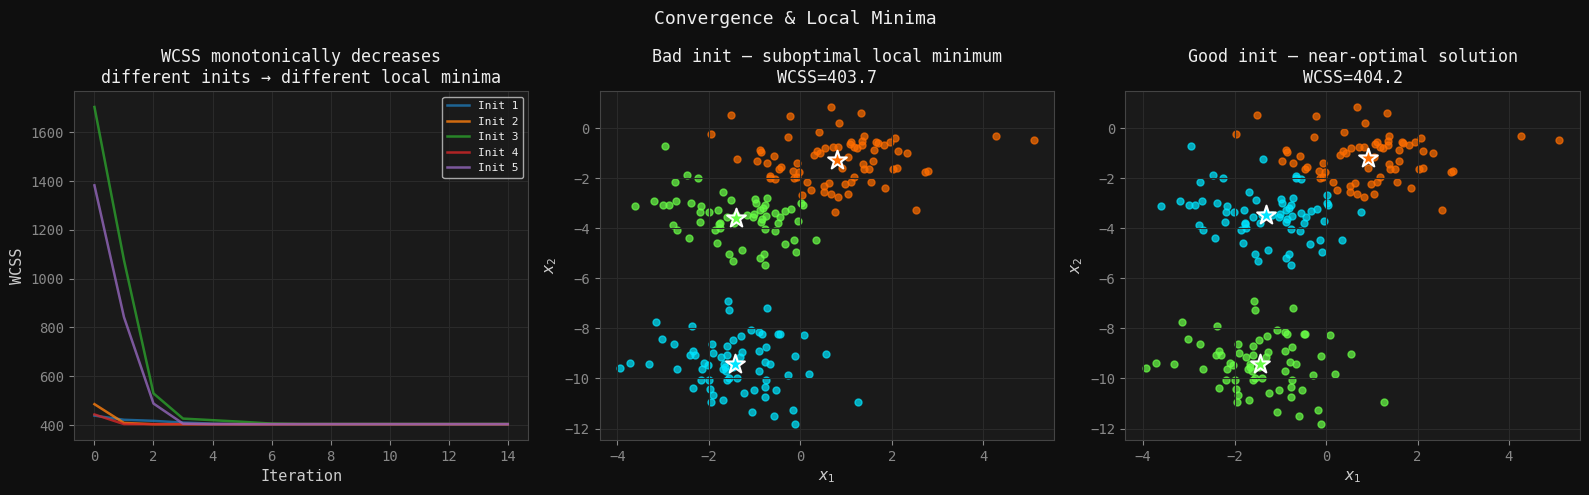

In [4]:
# Show convergence and multiple restarts
np.random.seed(2)
X_conv, _ = make_blobs(n_samples=200, centers=3, cluster_std=1.0, random_state=2)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Convergence & Local Minima', fontsize=13)

# WCSS decreasing across iterations
ax = axes[0]
wcss_history_runs = []
for seed in range(5):
    np.random.seed(seed * 17)
    cents = X_conv[np.random.choice(len(X_conv), 3, replace=False)]
    wcss_run = []
    for _ in range(15):
        labels, cents = kmeans_step(X_conv, cents)
        wcss_run.append(sum(np.sum((X_conv[labels==k]-cents[k])**2)
                            for k in range(3) if (labels==k).any()))
    wcss_history_runs.append(wcss_run)
    ax.plot(wcss_run, lw=1.8, alpha=0.8, label=f'Init {seed+1}')
ax.set_xlabel('Iteration'); ax.set_ylabel('WCSS')
ax.set_title('WCSS monotonically decreases\ndifferent inits → different local minima')
ax.legend(fontsize=8); ax.grid(True)

# Two local minima: good vs bad init
for ax, seed, title in [
    (axes[1], 99, 'Bad init — suboptimal local minimum'),
    (axes[2], 0,  'Good init — near-optimal solution'),
]:
    np.random.seed(seed)
    cents_init = X_conv[np.random.choice(len(X_conv), 3, replace=False)]
    for _ in range(20):
        labels, cents_init = kmeans_step(X_conv, cents_init)
    wcss_f = sum(np.sum((X_conv[labels==k]-cents_init[k])**2)
                 for k in range(3) if (labels==k).any())
    for k in range(3):
        mask = labels == k
        ax.scatter(X_conv[mask,0], X_conv[mask,1],
                   color=CLUSTER_COLORS[k], s=25, alpha=0.7)
        if mask.any():
            ax.scatter(*cents_init[k], color=CLUSTER_COLORS[k], s=200,
                       marker='*', zorder=6, edgecolors='white', linewidth=1.5)
    ax.set_title(f'{title}\nWCSS={wcss_f:.1f}')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.grid(True)

plt.tight_layout()
plt.savefig('img/km03_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Choosing K — Elbow Method & Silhouette Score

### Elbow Method

Plot WCSS vs K. WCSS always decreases as K increases (at $K=n$, WCSS$=0$). Look for the **elbow** — the point of diminishing returns where adding another cluster gives little improvement.

Mathematically, we are looking for the K where the marginal decrease $\Delta_K = \text{WCSS}(K-1) - \text{WCSS}(K)$ drops sharply. The elbow is subjective and often ambiguous.

### Silhouette Score

For each sample $i$, define:
- $a_i$ — mean distance to all other samples **in the same cluster** (cohesion)
- $b_i$ — mean distance to all samples in the **nearest other cluster** (separation)

The silhouette coefficient:
$$s_i = \frac{b_i - a_i}{\max(a_i, b_i)} \in [-1, 1]$$

- $s_i \approx 1$ — point is well inside its cluster, far from others
- $s_i \approx 0$ — point is near the boundary between clusters
- $s_i < 0$ — point is closer to another cluster (possible misassignment)

The mean silhouette score $\bar{s} = \frac{1}{n}\sum_i s_i$ measures overall clustering quality. **Choose K that maximises $\bar{s}$**.

NameError: name 'WHITE' is not defined

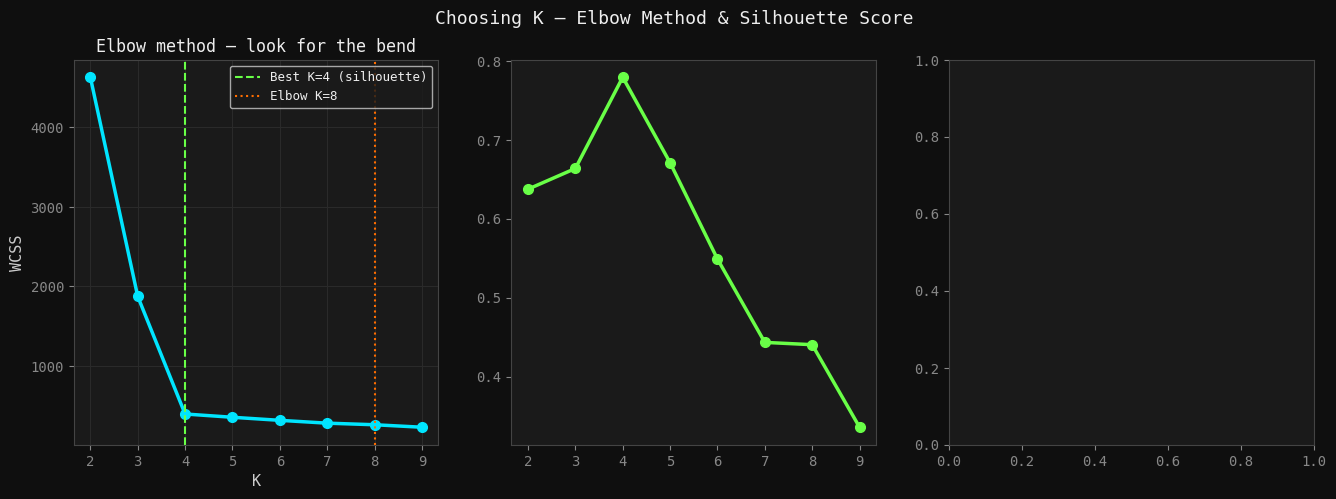

In [5]:
np.random.seed(3)
X_k, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=3)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Choosing K — Elbow Method & Silhouette Score', fontsize=13)

k_range = range(2, 10)
wcss_vals, sil_vals = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels_k = km.fit_predict(X_k)
    wcss_vals.append(km.inertia_)
    sil_vals.append(silhouette_score(X_k, labels_k))

# Elbow
ax = axes[0]
ax.plot(list(k_range), wcss_vals, color=ACCENT, lw=2.5, marker='o', ms=7)
best_k_sil = list(k_range)[np.argmax(sil_vals)]
ax.axvline(best_k_sil, color=GREEN, lw=1.5, linestyle='--', label=f'Best K={best_k_sil} (silhouette)')
deltas = np.diff(wcss_vals)
elbow_k = list(k_range)[np.argmin(np.diff(deltas)) + 1]
ax.axvline(elbow_k, color=ORANGE, lw=1.5, linestyle=':', label=f'Elbow K={elbow_k}')
ax.set_xlabel('K'); ax.set_ylabel('WCSS')
ax.set_title('Elbow method — look for the bend')
ax.legend(fontsize=9); ax.grid(True)

# Silhouette scores
ax = axes[1]
ax.plot(list(k_range), sil_vals, color=GREEN, lw=2.5, marker='o', ms=7)
ax.scatter(best_k_sil, max(sil_vals), color=WHITE, s=150, zorder=5, label=f'Best K={best_k_sil}')
ax.set_xlabel('K'); ax.set_ylabel('Mean silhouette score')
ax.set_title('Silhouette score — higher = better\n(max at true K=4)')
ax.legend(fontsize=9); ax.grid(True)

# Per-sample silhouette at K=4
ax = axes[2]
km4 = KMeans(n_clusters=4, random_state=0, n_init=10)
labels_4 = km4.fit_predict(X_k)
sil_samples = silhouette_samples(X_k, labels_4)
y_pos = 0
for k in range(4):
    sil_k = np.sort(sil_samples[labels_4 == k])
    ax.barh(range(y_pos, y_pos + len(sil_k)), sil_k, height=1.0,
            color=CLUSTER_COLORS[k], alpha=0.8)
    y_pos += len(sil_k) + 5
ax.axvline(np.mean(sil_samples), color=WHITE, lw=2, linestyle='--',
           label=f'Mean={np.mean(sil_samples):.3f}')
ax.set_xlabel('Silhouette coefficient $s_i$')
ax.set_title('Per-sample silhouette at K=4\nnegative values = possible misassignment')
ax.legend(fontsize=9); ax.grid(True, axis='x')

plt.tight_layout()
plt.savefig('img/km04_choosing_k.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Initialisation — K-Means++

Random initialisation often leads to poor local minima. **K-Means++** (Arthur & Vassilvitskii, 2007) spreads the initial centroids across the data:

**Algorithm**:
1. Choose the first centroid $\mu_1$ uniformly at random from $\mathcal{D}$
2. For $k = 2, \ldots, K$:
   - Compute $d_i = \min_{j < k} \|x_i - \mu_j\|^2$ — squared distance to nearest chosen centroid
   - Choose $\mu_k = x_i$ with probability $\propto d_i$ — points farther away are more likely to be chosen
3. Run standard Lloyd's algorithm from these initialised centroids

**Intuition**: by weighting the probability by squared distance, K-Means++ tends to spread centroids across the data rather than clustering them in one region.

**Theoretical guarantee**: the expected WCSS of K-Means++ initialisation is $\mathcal{O}(\log K)$ times the optimal WCSS — a substantial improvement over random initialisation which has no such bound.

This is the default in sklearn (`init='k-means++'`).

In [ ]:
np.random.seed(4)
X_pp, _ = make_blobs(n_samples=200, centers=5, cluster_std=1.0, random_state=4)

def kmeans_pp_init(X, K):
    """K-Means++ initialisation, returns centroids and selection probs."""
    idx = np.random.randint(len(X))
    centroids = [X[idx]]
    prob_history = []
    for _ in range(K - 1):
        dists = np.array([min(np.sum((x - c)**2) for c in centroids) for x in X])
        probs = dists / dists.sum()
        prob_history.append(probs.copy())
        idx = np.random.choice(len(X), p=probs)
        centroids.append(X[idx])
    return np.array(centroids), prob_history

np.random.seed(7)
centroids_pp, prob_hist_pp = kmeans_pp_init(X_pp, 5)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('K-Means++ Initialisation — Spreading Centroids by Distance', fontsize=13)

# Show probability distribution after first centroid
ax = axes[0]
ax.scatter(X_pp[:,0], X_pp[:,1], c='#555', s=20, alpha=0.5)
ax.scatter(*centroids_pp[0], color=WHITE, s=300, marker='*', zorder=6, label='1st centroid')
probs_1 = prob_hist_pp[0]
sc = ax.scatter(X_pp[:,0], X_pp[:,1], c=probs_1, cmap='hot', s=40, alpha=0.8, zorder=4)
plt.colorbar(sc, ax=ax, label='$P(\\text{select}) \\propto d^2$')
ax.set_title('Selection probability after 1st centroid\n— far points are more likely chosen')
ax.legend(fontsize=9); ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.grid(True)

# Final K-Means++ init positions
ax = axes[1]
ax.scatter(X_pp[:,0], X_pp[:,1], c='#555', s=20, alpha=0.5)
colors_pp = [WHITE, ACCENT, GREEN, ORANGE, RED]
for i, c in enumerate(centroids_pp):
    ax.scatter(*c, color=colors_pp[i], s=300, marker='*', zorder=6,
               edgecolors='white', linewidth=1, label=f'Centroid {i+1}')
ax.set_title('K-Means++ initial centroids\n— well spread, not clustered')
ax.legend(fontsize=8); ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.grid(True)

# Compare random vs K-Means++ WCSS over many runs
ax = axes[2]
wcss_random, wcss_pp = [], []
for seed in range(50):
    km_rand = KMeans(n_clusters=5, init='random', n_init=1, random_state=seed)
    km_pp   = KMeans(n_clusters=5, init='k-means++', n_init=1, random_state=seed)
    wcss_random.append(km_rand.fit(X_pp).inertia_)
    wcss_pp.append(km_pp.fit(X_pp).inertia_)
ax.hist(wcss_random, bins=20, color=RED,   alpha=0.6, label=f'Random (mean={np.mean(wcss_random):.0f})')
ax.hist(wcss_pp,     bins=20, color=GREEN, alpha=0.6, label=f'K-Means++ (mean={np.mean(wcss_pp):.0f})')
ax.set_xlabel('Final WCSS'); ax.set_ylabel('Count')
ax.set_title('50 runs: K-Means++ finds better solutions\n— lower and less variable WCSS')
ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.savefig('img/km05_kmeanspp.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Limitations & When K-Means Fails

K-Means makes implicit assumptions — it works best when clusters are **convex, isotropic, and of similar size**. It fails systematically when these assumptions are violated.

**Assumption 1 — Spherical clusters**: K-Means uses Euclidean distance, which treats all directions equally. Elongated or diagonal clusters will be split incorrectly.

**Assumption 2 — Similar cluster sizes**: the Voronoi partition assigns each point to its nearest centroid regardless of cluster density. A small tight cluster surrounded by a large sparse one will lose points to the large cluster.

**Assumption 3 — Convex clusters**: non-convex shapes (rings, moons, interleaved spirals) cannot be separated by Voronoi cells — linear decision boundaries cannot capture curved cluster shapes.

**Assumption 4 — Known K**: K-Means requires the number of clusters as input. In practice this is unknown, and the elbow/silhouette methods often give ambiguous answers.

**Alternatives for non-spherical data**:
- **DBSCAN** — density-based, no K required, handles arbitrary shapes, marks outliers
- **GMM** — probabilistic, handles elliptical clusters, provides soft assignments
- **Spectral clustering** — uses eigenvectors of the similarity graph, handles non-convex shapes
- **HDBSCAN** — hierarchical density-based, robust to varying densities

In [ ]:
from sklearn.datasets import make_circles, make_moons
from sklearn.preprocessing import StandardScaler

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('When K-Means Fails — Violated Assumptions', fontsize=13)

# Anisotropic (elongated) clusters
np.random.seed(0)
X_aniso, y_aniso = make_blobs(n_samples=300, centers=3, random_state=0)
transform = np.array([[0.6, -0.6], [-0.4, 0.8]])
X_aniso = X_aniso @ transform
km_aniso = KMeans(n_clusters=3, random_state=0, n_init=10)
labels_aniso = km_aniso.fit_predict(X_aniso)
for ax, labels, title in [
    (axes[0][0], y_aniso, 'True (elongated clusters)'),
    (axes[1][0], labels_aniso, 'K-Means (splits elongated clusters wrong)'),
]:
    for k in np.unique(labels):
        mask = labels == k
        ax.scatter(X_aniso[mask,0], X_aniso[mask,1],
                   color=CLUSTER_COLORS[k], s=20, alpha=0.7)
    ax.set_title(title); ax.grid(True)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

# Different-sized clusters
np.random.seed(1)
centers = [[0,0],[5,5],[10,0]]
X_diff, y_diff = make_blobs(n_samples=[200, 50, 300], centers=centers,
                             cluster_std=[0.5, 0.5, 2.0], random_state=1)
km_diff = KMeans(n_clusters=3, random_state=0, n_init=10)
labels_diff = km_diff.fit_predict(X_diff)
for ax, labels, title in [
    (axes[0][1], y_diff, 'True (different sizes & densities)'),
    (axes[1][1], labels_diff, 'K-Means (fails with unequal sizes)'),
]:
    for k in np.unique(labels):
        mask = labels == k
        ax.scatter(X_diff[mask,0], X_diff[mask,1],
                   color=CLUSTER_COLORS[k], s=20, alpha=0.7)
    ax.set_title(title); ax.grid(True)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

# Non-convex (rings)
np.random.seed(2)
X_circles, y_circles = make_circles(n_samples=300, factor=0.5, noise=0.05, random_state=2)
km_circles = KMeans(n_clusters=2, random_state=0, n_init=10)
labels_circles = km_circles.fit_predict(X_circles)
for ax, labels, title in [
    (axes[0][2], y_circles, 'True (concentric rings — non-convex)'),
    (axes[1][2], labels_circles, 'K-Means (splits horizontally, not by ring)'),
]:
    for k in np.unique(labels):
        mask = labels == k
        ax.scatter(X_circles[mask,0], X_circles[mask,1],
                   color=CLUSTER_COLORS[k], s=20, alpha=0.7)
    ax.set_title(title); ax.set_aspect('equal'); ax.grid(True)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

plt.tight_layout()
plt.savefig('img/km06_limitations.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Key Takeaways

1. K-Means minimises **WCSS** $= \sum_k\sum_{i\in C_k}\|x_i-\mu_k\|^2$. The centroid $\mu_k$ is the unique minimiser of squared distances — derived from setting $\partial/\partial\mu_k = 0$.
2. **Lloyd's algorithm** alternates E-step (assign to nearest centroid) and M-step (update centroid to cluster mean). WCSS decreases monotonically — guaranteed to converge, not guaranteed to find the global minimum.
3. **K-Means++ initialisation** weights centroid selection by $d^2$ (squared distance to nearest chosen centroid), spreading initial centroids across the data. Expected WCSS is $\mathcal{O}(\log K)$-optimal.
4. **Choose K** using the elbow method (look for the bend in WCSS vs K) or the silhouette score $s_i = (b_i - a_i)/\max(a_i, b_i)$ — maximise the mean silhouette.
5. K-Means assumes **spherical, equally-sized, convex clusters**. It fails systematically on elongated, unequally-sized, or non-convex shapes.
6. **Run multiple times** (`n_init=10` in sklearn) — different initialisations converge to different local minima.

---
*Previous: [`06_xgboost.ipynb`](./06_xgboost.ipynb) · Next: [`08_gmm_em.ipynb`](./08_gmm_em.ipynb)*